In [15]:
import CoolProp

In CoolProp, Q represents the vapor quality (or mass fraction of vapor) in a two-phase liquid-vapor mixture. It is used as an input parameter for saturation properties, where Q=0 is a saturated liquid (bubble point), Q=1 is a saturated vapor (dew point), and 0>Q>1 indicates a mixture.

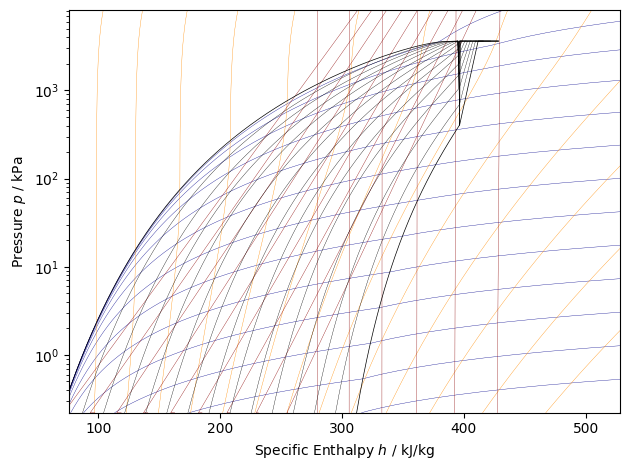

In [16]:
from CoolProp.Plots import PropertyPlot
plot = PropertyPlot('R1234ZE', 'ph')
plot.calc_isolines()
plot.show()

In [17]:
temp_sat_liq = CoolProp.CoolProp.PropsSI(
    'T','P',101325,'Q',0,'R1234ZE'
)
print(f"Saturated liquid temperature of R1234ZE at 1atm: {temp_sat_liq:.3f}K, type: {type(temp_sat_liq)}")

Saturated liquid temperature of R1234ZE at 1atm: 254.177K, type: <class 'float'>


In [18]:
temp_sat_vap = CoolProp.CoolProp.PropsSI(
    'T', 'P', 101325, 'Q', 1, 'R1234ZE'
)
print(f"Saturated vapor temperature of R1234ZE at 1atm: {temp_sat_vap:.3f}K, type: {type(temp_sat_vap)}")

Saturated vapor temperature of R1234ZE at 1atm: 254.177K, type: <class 'float'>


In [19]:
print(temp_sat_liq == temp_sat_vap)
temp_sat = temp_sat_liq

True


### Why do saturated liquid and saturated vapor have the same temperature?

At a given pressure, there is only one temperature at which a fluid can exist in equilibrium between liquid and vapor phases: the saturation temperature.

Under these conditions, the liquid evaporates and the vapor condenses at the same rate, so the system is stable and both phases coexist. If the temperature increases, evaporation dominates (superheated vapor); if it decreases, condensation dominates (subcooled liquid).

For this reason:

* Q = 0 (saturated liquid), and
* Q = 1 (saturated vapor)

have the same temperature at the same pressure: they represent the two extremes of the same phase-change process.

During this process, the energy supplied does not increase the temperature but instead changes the phase (latent heat), causing the vapor quality (Q) to vary.

In [20]:
h_sat_liq = CoolProp.CoolProp.PropsSI(
    'H', 'P', 101325, 'Q', 0, 'R1234ZE'
)
h_sat_vap = CoolProp.CoolProp.PropsSI(
    'H', 'P', 101325, 'Q', 1, 'R1234ZE'
)

print(f"Enthalpy on the saturated liquid line: {h_sat_liq:.3f}J/kg")
print(f"Enthalpy on the saturated vapor line: {h_sat_vap:.3f}J/kg")

Enthalpy on the saturated liquid line: 175311.715J/kg
Enthalpy on the saturated vapor line: 370932.860J/kg


In [21]:
h_mixture = CoolProp.CoolProp.PropsSI(
    'H', 'P', 101325, 'Q', 0.2, 'R1234ZE'
)
h_mixture

214435.94364747696

In [22]:
# h(Q) ≈ h_liq + Q * (h_vap - h_liq)
h_sat_liq + 0.2 * (h_sat_vap - h_sat_liq)

214435.94364747696

In [23]:
# Superheated gas enthalpy
sh_temp = temp_sat_vap + 10
h_sh = CoolProp.CoolProp.PropsSI(
    'H', 'P', 101325, 'T', sh_temp, 'R1234ZE'
)
print(f"Superheated gas enthalpy: {h_sh:.3f}J/kg")
print(h_sh > h_sat_vap)

Superheated gas enthalpy: 379292.332J/kg
True


In [24]:
# Subcooled gas enthalpy
sc_temp = temp_sat_liq - 10
h_sc = CoolProp.CoolProp.PropsSI(
    'H', 'P', 101325, 'T', sc_temp, 'R1234ZE'
)
print(f"Subcooled liquid enthalpy: {h_sc:.3f}J/kg")
print(h_sc < h_sat_liq)

Subcooled liquid enthalpy: 162572.171J/kg
True


In [25]:
def get_state_PT(P, T, fluid):
    """
    Determine the thermodynamic state of a fluid given pressure (P) and temperature (T).

    This function acts as a wrapper around CoolProp to compute thermodynamic
    properties while explicitly handling the ambiguity that arises at saturation.

    -------------------------
    THEORETICAL BACKGROUND
    -------------------------

    In thermodynamics, a state is usually defined by two independent properties.
    In single-phase regions (subcooled liquid or superheated vapor), the pair (P, T)
    uniquely determines the state and all other properties (e.g., enthalpy h,
    entropy s) can be computed unambiguously.

    However, at saturation conditions, this is no longer true.

    For a given pressure P, there exists a unique saturation temperature T_sat
    at which liquid and vapor can coexist in equilibrium. At this point:

        - T = T_sat(P)
        - The fluid can be in a two-phase mixture
        - The state is not uniquely defined by (P, T)

    Instead, an additional variable is required:
        - Vapor quality Q (mass fraction of vapor)

    Because Q is unknown in this function, properties such as enthalpy (h) and
    entropy (s) are not uniquely defined at saturation.

    -------------------------
    IMPLEMENTATION LOGIC
    -------------------------

    The function classifies the state into three regions:

    1. Subcooled liquid (T < T_sat)
        - The state is single-phase liquid
        - h and s are uniquely defined and computed using (P, T)

    2. Superheated vapor (T > T_sat)
        - The state is single-phase vapor
        - h and s are uniquely defined and computed using (P, T)

    3. Saturation region (T ≈ T_sat within tolerance)
        - The state is on the saturation curve
        - The fluid may be a mixture of liquid and vapor
        - h and s are NOT uniquely defined
        - The function returns:
            - h_liq, s_liq → saturated liquid properties (Q = 0)
            - h_vap, s_vap → saturated vapor properties (Q = 1)

        This represents the range of physically possible states.

    A tolerance is used to handle numerical precision issues when comparing T and T_sat.

    -------------------------
    RETURNS
    -------------------------

    dict with the following fields:

        P, T         : input pressure and temperature
        T_sat        : saturation temperature at given pressure
        phase        : "subcooled liquid", "superheated vapor", or "saturated"

        h, s         : defined only in single-phase regions
        h_liq, s_liq : defined only at saturation (Q = 0)
        h_vap, s_vap : defined only at saturation (Q = 1)

    Notes:
        - In the saturation region, 'h' and 's' are None because the state is not uniquely defined.
        - In single-phase regions, 'h_liq' and 'h_vap' are None.

    -------------------------
    KEY INSIGHT
    -------------------------

    This function highlights an important thermodynamic limitation:

        (P, T) does NOT always uniquely define a state.

    In two-phase regions, an additional variable (e.g., vapor quality Q)
    is required to fully describe the system.
    """
    result = {
    "P": P,
    "T": T,
    "T_sat": None,
    "phase": None,
    "h": None,
    "s": None,
    "h_liq": None,
    "s_liq": None,
    "h_vap": None,
    "s_vap": None
    }
    
    tol = 1e-3
    result['T_sat'] = CoolProp.CoolProp.PropsSI('T', 'P', P, 'Q', 0, fluid)
    if T < result['T_sat'] - tol:
        result['phase'] = "subcooled liquid"
        result['h'] = CoolProp.CoolProp.PropsSI('H', 'P', P, 'T', T, fluid)
        result['s'] = CoolProp.CoolProp.PropsSI('S', 'P', P, 'T', T, fluid)
    elif T > result['T_sat'] + tol:
        result['phase'] = "superheated vapor"
        result['h'] = CoolProp.CoolProp.PropsSI('H', 'P', P, 'T', T, fluid)
        result['s'] = CoolProp.CoolProp.PropsSI('S', 'P', P, 'T', T, fluid)
    else:
        result['phase'] = "saturated"
        result['h_liq'] = CoolProp.CoolProp.PropsSI('H', 'P', P, 'Q', 0, fluid)
        result['s_liq'] = CoolProp.CoolProp.PropsSI('S', 'P', P, 'Q', 0, fluid)
        result['h_vap'] = CoolProp.CoolProp.PropsSI('H', 'P', P, 'Q', 1, fluid)
        result['s_vap'] = CoolProp.CoolProp.PropsSI('S', 'P', P, 'Q', 1, fluid)
    return result

In [26]:
# Tests
print(get_state_PT(101325, temp_sat - 10, 'R1234ZE'))
print(get_state_PT(101325, temp_sat, 'R1234ZE'))
print(get_state_PT(101325, temp_sat + 10, 'R1234ZE'))

{'P': 101325, 'T': 244.17747497572307, 'T_sat': 254.17747497572307, 'phase': 'subcooled liquid', 'h': 162572.1710834784, 's': 855.5663243831415, 'h_liq': None, 's_liq': None, 'h_vap': None, 's_vap': None}
{'P': 101325, 'T': 254.17747497572307, 'T_sat': 254.17747497572307, 'phase': 'saturated', 'h': None, 's': None, 'h_liq': 175311.7145958169, 's_liq': 906.6974501484809, 'h_vap': 370932.8598541172, 's_vap': 1676.3216872174203}
{'P': 101325, 'T': 264.17747497572304, 'T_sat': 254.17747497572307, 'phase': 'superheated vapor', 'h': 379292.33216927847, 's': 1708.5778631240737, 'h_liq': None, 's_liq': None, 'h_vap': None, 's_vap': None}


In [27]:
def get_state_PH(P, h, fluid):
    """
    Determine the thermodynamic state of a fluid given pressure (P) and enthalpy (h).

    This function provides a robust way to compute the thermodynamic state using
    the (P, h) pair, which is valid in both single-phase and two-phase regions.

    -------------------------
    THEORETICAL BACKGROUND
    -------------------------

    In thermodynamics, a state is defined by two independent properties.
    Unlike (P, T), the pair (P, h) uniquely defines the state even in the
    two-phase region.

    At a given pressure P:
        - h_liq → enthalpy of saturated liquid (Q = 0)
        - h_vap → enthalpy of saturated vapor (Q = 1)

    The phase of the fluid can be determined by comparing h with these limits:

        - h < h_liq → subcooled liquid
        - h > h_vap → superheated vapor
        - h_liq ≤ h ≤ h_vap → two-phase (saturated mixture)

    In the two-phase region, the vapor quality Q can be computed as:

        Q = (h - h_liq) / (h_vap - h_liq)

    -------------------------
    IMPLEMENTATION LOGIC
    -------------------------

    1. Compute saturation properties at given pressure:
        - h_liq, h_vap
        - s_liq, s_vap

    2. Determine the phase by comparing h with saturation limits

    3. Compute temperature:
        - obtained directly from (P, h)
        - in two-phase region, this corresponds to saturation temperature

    4. Compute entropy (s):
        - single-phase → directly from CoolProp
        - two-phase → linear interpolation using Q

    -------------------------
    RETURNS
    -------------------------

    dict with the following fields:

        P      : pressure [Pa]
        T      : temperature [K]
        phase  : "subcooled liquid", "superheated vapor", or "saturated"
        h      : enthalpy [J/kg]
        s      : entropy [J/kg/K]
        Q      : vapor quality (None if single-phase)

    Notes:
        - In the two-phase region, Q ∈ [0, 1]
        - In single-phase regions, Q is None
        - Temperature in two-phase region equals saturation temperature

    -------------------------
    KEY INSIGHT
    -------------------------

    The pair (P, h) uniquely defines the thermodynamic state even in the
    saturation region, making it more suitable than (P, T) for modeling
    real thermodynamic cycles (e.g., compressors, expansion valves).
    """
    result = {
    "P": None,
    "T": None,
    "phase": None,
    "h": None,
    "s": None,
    "Q": None,
    }
    result['P'] = P
    result['h'] = h
    result['T'] = CoolProp.CoolProp.PropsSI('T', 'P', P, 'H', h, fluid)

    h_liq = CoolProp.CoolProp.PropsSI('H', 'P', P, 'Q', 0, fluid)
    h_vap = CoolProp.CoolProp.PropsSI('H', 'P', P, 'Q', 1, fluid)
    s_liq = CoolProp.CoolProp.PropsSI('S', 'P', P, 'Q', 0, fluid)
    s_vap = CoolProp.CoolProp.PropsSI('S', 'P', P, 'Q', 1, fluid)
    tol = 1e-3
    if h < h_liq - tol:
        result['phase'] = "subcooled liquid"
        result['Q'] = None
        result['s'] = CoolProp.CoolProp.PropsSI('S', 'P', P, 'H', h, fluid)
    elif h > h_vap + tol:
        result['phase'] = "superheated vapor"
        result['Q'] = None
        result['s'] = CoolProp.CoolProp.PropsSI('S', 'P', P, 'H', h, fluid)
    else:
        result["phase"] = "saturated"
        Q_raw = (h - h_liq)/(h_vap - h_liq)
        if Q_raw < -1e-6 or Q_raw > 1 + 1e-6:
            raise ValueError("Inconsistent state: h outside saturation bounds")
        Q = max(0.0, min(1.0, Q_raw))
    return result    

In [28]:
# Tests
P = 101325
fluid = 'R1234ZE'
h_liq = CoolProp.CoolProp.PropsSI('H', 'P', P, 'Q', 0, fluid)
h_vap = CoolProp.CoolProp.PropsSI('H', 'P', P, 'Q', 1, fluid)

# Subcooled liquid
state = get_state_PH(P, h_liq - 10000, fluid)
print(state)

# Saturated mixture
h_mid = (h_liq + h_vap) / 2
state = get_state_PH(P, h_mid, fluid)
print(state)

# Superheated vapor
state = get_state_PH(P, h_vap + 10000, fluid)
print(state)

# Edge case (saturated liquid)
state = get_state_PH(P, h_liq, fluid)
print(state)

# Edge case (saturated vapor)
state = get_state_PH(P, h_vap, fluid)
print(state)

{'P': 101325, 'T': 246.3382707504003, 'phase': 'subcooled liquid', 'h': 165311.7145958169, 's': 866.736429076024, 'Q': None}
{'P': 101325, 'T': 254.17747497572307, 'phase': 'saturated', 'h': 273122.28722496703, 's': None, 'Q': None}
{'P': 101325, 'T': 266.12115817241107, 'phase': 'superheated vapor', 'h': 380932.8598541172, 's': 1714.76506333583, 'Q': None}
{'P': 101325, 'T': 254.17747497572307, 'phase': 'saturated', 'h': 175311.7145958169, 's': None, 'Q': None}
{'P': 101325, 'T': 254.17747497572307, 'phase': 'saturated', 'h': 370932.8598541172, 's': None, 'Q': None}
